In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
x1_vals = torch.linspace(-0.3, 0.3, 20)
x2_vals = torch.linspace(-0.3, 0.3, 20)
X1, X2 = torch.meshgrid(x1_vals, x2_vals)
state_x12 = torch.column_stack((X1.ravel(), X2.ravel()))

/home/nazim/.local/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
N = 2
params = [(torch.rand(2)*10, torch.rand(2)*10) for _ in range(N)]


r = 0
for i in range(N):
    mu, var = params[i]
    sigma = torch.diag(var)
    r += gaussian_nd(state_x12, mu, sigma)

# r = torch.clip(r, -1, 1)
# r = r / r.max()
r = torch.tanh(r)


NameError: name 'gaussian_nd' is not defined

In [4]:

def gaussian_nd(x, mu, sigma):
    D = mu.shape[0]
    inv_sigma = torch.inverse(sigma)  # Compute the inverse covariance matrix
    det_sigma = torch.det(sigma)  # Compute the determinant of the covariance matrix

    diff = x - mu  # Shape: (N, D)
    exponent = -0.5 * torch.sum(diff @ inv_sigma * diff, dim=1)  # Shape: (N,)

    normalization_constant = (2 * torch.pi) ** (D / 2) * torch.sqrt(det_sigma)
    normalization_constant = 1
    
    return torch.exp(exponent) / normalization_constant
    
    
class GuassianMixtureReward:
    def __init__(self, obs_dim, num_guassians):
        self.obs_dim = obs_dim
        self.num_guassians = num_guassians
        self.len_params = num_guassians * 2 * self.obs_dim

    
    def tensor2list(self, tensor_param):
        # tensor_param.shape == (batch_size, len_params)
        assert len(tensor_param.shape) == 2
        assert tensor_param.shape[1] == self.len_params
        
        batch_size = tensor_param.shape[0]
        obs_dim = self.obs_dim
        
        res = []
        for b in range(batch_size):
            list_param = []
            for i in range(0, len(tensor_param[b]), obs_dim*2):
                mu = tensor_param[b] [i:i+obs_dim]
                var = tensor_param[b][i+obs_dim:i + obs_dim*2]
                list_param.append((mu, var))
            res.append(list_param)
        # print(res)
        return res
    
    
    def one_random_sample(self):
        params = []
        info = []
        for _  in range(self.num_guassians):
            mu = torch.rand(self.obs_dim)
            # mu[:2] = torch.tensor([0.25, 0.25])
            mu[:2] = torch.rand(2) * 0.6 - 0.3
            mu[2:] = torch.rand(2) * 0.1 - 0.05
            
            
            var = torch.rand(self.obs_dim) * 0.1
            
            params.append(mu)
            params.append(var)
            info.append({'mu':mu, 'var':var})
        return torch.concatenate(params), info
    
    
    def sample(self, N):
        params_stack = []
        info_stack = []
        for _ in range(N):
            params, info = self.one_random_sample()
            params_stack.append(params)
            info_stack.append(info)
            
        params_stack = torch.stack(params_stack)
        return params_stack, info_stack


    # def get_reward(self, obs, params):
    #     # obs.shape == (batch_size, obs_len)
    #     # params.shape == (batch_size, len_params)
    #     assert obs.shape[0] == params.shape[0]
    #     assert len(obs.shape) == 2 
    #     assert params.shape[1] == self.len_params
        
    #     batch_size = obs.shape[0]
        
    #     rewards = []
    #     for b in tqdm(range(batch_size)):
    #         r = 0
    #         params_list = self.tensor2list(params[b:b+1])[0]
    #         for mu, var in params_list:
    #             # print(mu, var)
    #             sigma = torch.diag(var)
    #             r += gaussian_nd(obs[b:b+1], mu, sigma)
    #         r = torch.tanh(r)
    #         rewards.append(r)
        
    #     return torch.stack(rewards)

    
    def get_reward(self, obs, params):
        # obs.shape == (batch_size, obs_len)
        # params.shape == (batch_size, len_params)
        assert obs.shape[0] == params.shape[0]
        assert len(obs.shape) == 2 
        assert params.shape[1] == self.len_params
        
        params_mu_var = self.tensor2list(params)
        # print(params_mu_var[0])
        
        
        mu = torch.stack([torch.stack([mu for (mu, var) in mu_var]) for mu_var in params_mu_var])
        var = torch.stack([torch.stack([var for (mu, var) in mu_var]) for mu_var in params_mu_var])
        
        # print(mu.shape, var.shape)
        
        res = 0
        
        for i in range(self.num_guassians):
            
            m, v = mu[:, i, :], var[:, i, :]
            inv_sigma = torch.stack([torch.diag(1 / row) for row in v])
            
            # print(obs.shape, m.shape, inv_sigma.shape)

            # x = torch.rand((B, obs_len))
            
            diff = obs - m
            exponent = -0.5 * (diff.unsqueeze(1) @ inv_sigma) @ diff.unsqueeze(-1)

            res += torch.exp(exponent).flatten()
            
        return torch.tanh(res)

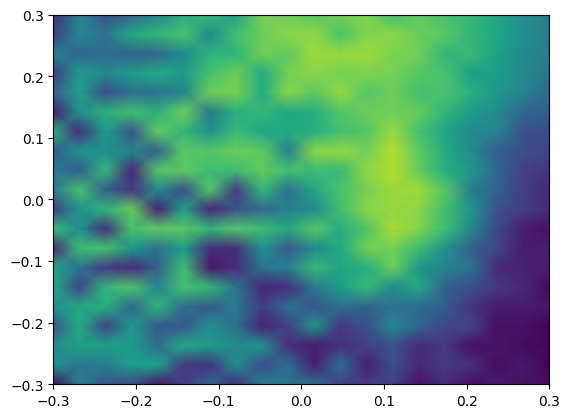

In [6]:

GMreward = GuassianMixtureReward(4, 3)
params, info = GMreward.sample(1)

params = params.unsqueeze(1).repeat(1, 400, 1).reshape(1*400, -1)

s = 20
x1_vals = np.linspace(-0.3, 0.3, s)
x2_vals = np.linspace(-0.3, 0.3, s)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))

state = torch.rand((s*s, 4)) * 0.6 - 0.3
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state

obs = state.unsqueeze(0).repeat(1, 1, 1).reshape(1*400, -1)

rewards = GMreward.get_reward(obs, params)


r = rewards.reshape(1, 400, -1)
plt.pcolormesh(X1, X2, r[0].reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=1, vmin=0, vmax=1)

# GMreward.tensor2list(params)

In [166]:
params_stack = []
for mu, sigma in params:
    params_stack.append(mu.flatten())
    params_stack.append(sigma.flatten())
torch.concatenate(params_stack).shape

torch.Size([120])

[tensor([8.3861, 0.9889]),
 tensor([[9.1064, 0.0000],
         [0.0000, 9.9494]])]

In [441]:
torch.rand(2, 2).T @ torch.rand(2, 2)

tensor([[0.7405, 0.3450],
        [0.7559, 0.3206]])

In [572]:
B = 8
obs_len = 2

mu = torch.rand((B, obs_len))
inv_sigma = torch.stack([
    torch.diag(1 / row) for row in torch.rand(B, obs_len)]
)

x = torch.rand((B, obs_len))

In [576]:
diff = x - mu
exponent = -0.5 * (diff.unsqueeze(1) @ inv_sigma) @ diff.unsqueeze(-1)
res = torch.exp(exponent).flatten()

res

tensor([0.6209, 0.6234, 0.7041, 0.7374, 0.5160, 0.7361, 0.8909, 0.7707])

In [570]:
res

tensor([[[0.3367]],

        [[2.1087]],

        [[1.9561]],

        [[3.4472]],

        [[2.1067]],

        [[1.5413]],

        [[0.5422]],

        [[1.7562]]])